# Content and Objective

+ Comparison of a strictly stationary and a weakly stationary process

## Import

In [1]:
# importing
import numpy as np
import shutil

import matplotlib.pyplot as plt
import matplotlib

# showing figures inline
%matplotlib inline

In [2]:
# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=True if shutil.which('latex') else False)

matplotlib.rc('figure', figsize=(13, 6) )

## Process 1: Strictly Stationary

We start with a strictly stationary, discrete-time process $X[n]$ where $X[n] \in \{\pm 1\}$ for $n\in\mathbb{Z}$ with
\begin{equation*}
P(X[n] = +1) = P(X[n] = -1) = \frac12
\end{equation*}
and the different $X[n]$ are independent.

In [3]:
def process_1(N, seed=None):  
    rng = np.random.default_rng(seed)
    
    n = np.arange(N)
    x = rng.choice([-1, 1], size=N)

    return n,x

Plot 6 realizations of the process

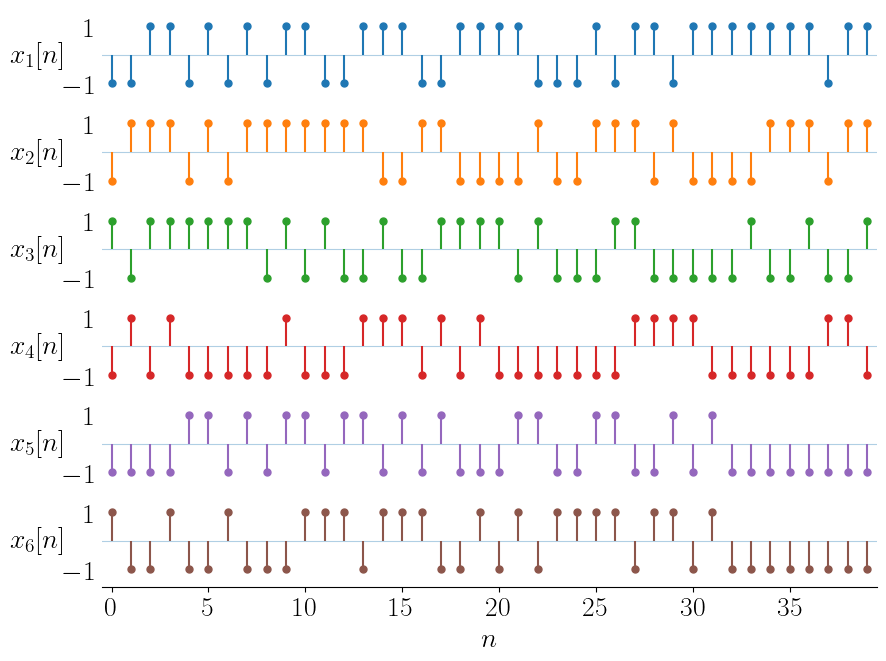

In [4]:
N = 40
n_realizations = 6

# Matplotlib default color cycle
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(
    n_realizations, 1,
    sharex=True,
    figsize=(10, 7.5),
    gridspec_kw={"hspace": 0.06}
)

for i, ax in enumerate(axes):
    n,x = process_1(N)
    
    color = colors[i % len(colors)]

    # light zero-reference line
    ax.axhline(0, linewidth=0.8, alpha=0.35, zorder=0)

    # stem plot
    markerline, stemlines, baseline = ax.stem(n, x, basefmt=" ")
    plt.setp(markerline, markersize=5, color=color)
    plt.setp(stemlines, linewidth=1.5, color=color)

    # y formatting
    ax.set_ylim(-1.6, 1.6)
    ax.set_yticks([-1, 1])
    ax.set_ylabel(fr"$x_{{{i+1}}}[n]$", rotation=0, labelpad=18, va="center")

    # clean look: remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    if i != n_realizations - 1:
        ax.spines["bottom"].set_visible(False)

    # simplify ticks
    ax.tick_params(axis="y", length=0)
    if i != n_realizations - 1:
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

axes[-1].set_xlabel("$n$")
axes[-1].set_xlim(-0.5, N - 0.5)

plt.show()

We can see that this process is strictly stationary, as we can pick any $N$ time instants $n_1,\ldots n_N$ abd have
\begin{equation*}
P(x[n_1], x[n_2], \ldots, x[n_N]) = \prod_{i=1}^NP(x[n_i]) = 2^{-N}
\end{equation*}
which is clearly independent of the time instants chosen. 

Furthermore, the process is also weakly stationary, as
\begin{align*}
\mathbb{E}\{X[n]\} &= +1\cdot P(X[n] = +1) - 1\cdot P(x[n] = -1) = 0 \\
\varphi_{XX}[k] &= \mathbb{E}\{X[n]X[n-k]\} = \begin{cases} 1 & k = 0 \\ 0 & \text{otherwise}\end{cases}
\end{align*}

## Process 2: Weakly Stationary (but not Strictly Stationary)

We now consider the second process, which is weakly stationary, but not strictly stationary, with
\begin{equation*}
Y[n] = A\cdot\cos\left(\frac{\pi n}{4}\right) + B\cdot\sin\left(\frac{\pi n}{4}\right)
\end{equation*}
where where A and B are independent random signs with $P(A=1)=P(A=−1)=\frac12$ and $P(B=1) = P(B=-1) = \frac12$.

In [5]:
def process_2(N, seed=None):  
    rng = np.random.default_rng(seed)
    
    A = rng.choice([-1, 1])
    B = rng.choice([-1, 1])

    n = np.arange(N)
    x = A * np.cos(np.pi * n / 4) + B * np.sin(np.pi * n / 4)

    return n,x

Plot 6 realizations of the process

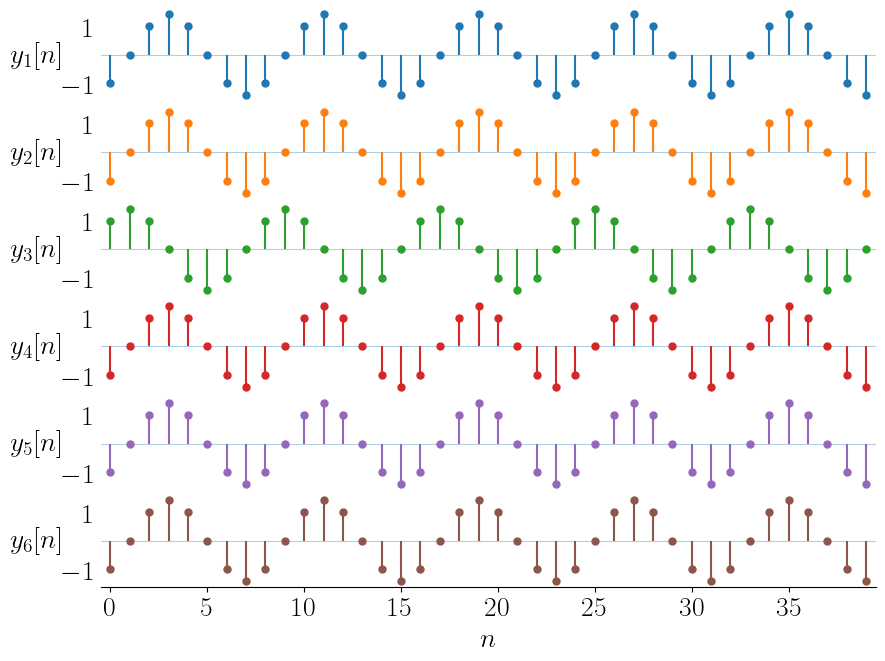

In [7]:
N = 40
n_realizations = 6

# Matplotlib default color cycle
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(
    n_realizations, 1,
    sharex=True,
    figsize=(10, 7.5),
    gridspec_kw={"hspace": 0.06}
)

for i, ax in enumerate(axes):
    n,x = process_2(N)
    
    color = colors[i % len(colors)]

    # light zero-reference line
    ax.axhline(0, linewidth=0.8, alpha=0.35, zorder=0)

    # stem plot
    markerline, stemlines, baseline = ax.stem(n, x, basefmt=" ")
    plt.setp(markerline, markersize=5, color=color)
    plt.setp(stemlines, linewidth=1.5, color=color)

    # y formatting
    ax.set_ylim(-1.6, 1.6)
    ax.set_yticks([-1, 1])
    ax.set_ylabel(fr"$y_{{{i+1}}}[n]$", rotation=0, labelpad=18, va="center")

    # clean look: remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    if i != n_realizations - 1:
        ax.spines["bottom"].set_visible(False)

    # simplify ticks
    ax.tick_params(axis="y", length=0)
    if i != n_realizations - 1:
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

axes[-1].set_xlabel("$n$")
axes[-1].set_xlim(-0.5, N - 0.5)

plt.show()

This process is weakly stationary because
\begin{align*}
\mathbb{E}\{Y[n]\} &= \mathbb{E}\{A\cdot\cos\left(\frac{\pi n}{4}\right) + B\cdot\sin\left(\frac{\pi n}{4}\right)\} \\
&= \mathbb{E}\{A\}\cdot\cos\left(\frac{\pi n}{4}\right) + \mathbb{E}\{B\}\cdot\sin\left(\frac{\pi n}{4}\right) \\
&= 0
\end{align*}
and
\begin{align*}
\varphi_{XX}[n,m] &= \mathbb{E}\{Y[n]Y[m]\} = \mathbb{E}\left\{\left[A\cdot\cos\left(\frac{\pi n}{4}\right) + B\cdot\sin\left(\frac{\pi n}{4}\right)\right]\left[A\cdot\cos\left(\frac{\pi m}{4}\right) + B\cdot\sin\left(\frac{\pi m}{4}\right)\right]\right\} \\
&= \mathbb{E}\{A^2\}\cos\left(\frac{\pi n}{4}\right)\cos\left(\frac{\pi m}{4}\right) +  \mathbb{E}\{B^2\}\sin\left(\frac{\pi n}{4}\right)\sin\left(\frac{\pi m}{4}\right) + \mathbb{E}\{AB\}\left[\cos\left(\frac{\pi n}{4}\right)\sin\left(\frac{\pi m}{4}\right) + \sin\left(\frac{\pi n}{4}\right)cos\left(\frac{\pi m}{4}\right)\right] \\
&\stackrel{(a)}{=} \cos\left(\frac{\pi n}{4}\right)\cos\left(\frac{\pi m}{4}\right) +  \sin\left(\frac{\pi n}{4}\right)\sin\left(\frac{\pi m}{4}\right) \\
&\stackrel{(b)}{=} \frac12\cos\left(\frac{\pi}{4}(n-m)\right) + \frac12\cos\left(\frac{\pi}{4}(n+m)\right) + \frac12\cos\left(\frac{\pi}{4}(n-m)\right) - \frac12\cos\left(\frac{\pi}{4}(n+m)\right) \\
&= \cos\left(\frac{\pi}{4}(n-m)\right) =: \cos\left(\frac{k\pi}{4}\right) =: \varphi_{XX}[k]
\end{align*}
where $(a)$ is due to the fact that $\mathbb{E}\{A^2\} = \mathbb{E}\{B^2\} = (+1)^2\frac12 + (-1)^2\frac12 = 1$ and $\mathbb{E}\{AB\} = (+1)(+1)\frac14 + (+1)(-1)\frac14 + (-1)(+1)\frac14 + (-1)(-1)\frac14 = 0$ and where $(b)$ uses $\cos(x)\cos(y) = \frac12\cos(x-y)+\frac12\cos(x+y)$ and $\sin(x)\sin(y) = \frac12\cos(x-y)-\frac12\cos(x+y)$.

The process $Y[n]$ is however not strictly stationary. Consider the probability mass function at time $n=0$ and time $n=1$. We have $Y[0] = A\cdot\cos\left(0\right) + B\cdot\sin\left(0\right) = A$. Hence
\begin{align*}
P(Y[0] = +1) = P(Y[0] = -1) = \frac12.
\end{align*}
In constract, we have $Y[1] = A\cdot\cos\left(\frac{\pi}{4}\right) + B\cdot\sin\left(\frac{\pi}{4}\right) = (A+B)\frac{\sqrt{2}}{2}$ and hance
\begin{align*}
P(Y[1] = y) = \begin{cases}
\frac14 & \text{if }y = \sqrt{2}\qquad (A = +1\text{ and }B = +1) \\
\frac14 & \text{if }y = -\sqrt{2}\qquad (A = -1\text{ and }B = -1) \\
\frac12 & \text{if }y = 0 \qquad (A = -1\text{ and }B = +1 \text{ or } A = +1\text{ and }B = -1)\end{cases}
\end{align*}
As the two probability mass functions are not constant after the time shift, we can conclude that the process is **not** strictly stationary.


The two distributions are plotted below:

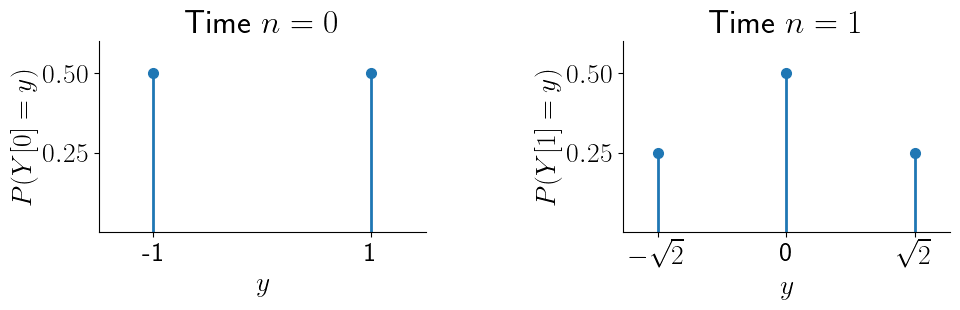

In [18]:
# --- n = 0 ---
x0_vals = np.array([-1, 1], dtype=float)
p0_vals = np.array([0.5, 0.5], dtype=float)

# --- n = 1 ---
r2 = np.sqrt(2)
x1_vals = np.array([-r2, 0, r2], dtype=float)
p1_vals = np.array([0.25, 0.5, 0.25], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Left: distribution at n = 0
ax = axes[0]
markerline, stemlines, baseline = ax.stem(x0_vals, p0_vals, basefmt=" ")
plt.setp(markerline, markersize=7)
plt.setp(stemlines, linewidth=2)

ax.set_title(r"Time $n=0$")
ax.set_xlabel("$y$")
ax.set_ylabel("$P(Y[0] = y)$")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(0, 0.6)
ax.set_xticks(x0_vals)
ax.set_xticklabels(["-1", "1"])
ax.set_yticks([0.25, 0.5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Right: distribution at n = 1
ax = axes[1]
markerline, stemlines, baseline = ax.stem(x1_vals, p1_vals, basefmt=" ")
plt.setp(markerline, markersize=7)
plt.setp(stemlines, linewidth=2)

ax.set_title(r"Time $n=1$")
ax.set_xlabel("$y$")
ax.set_ylabel("$P(Y[1] = y)$")
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(0, 0.6)
ax.set_xticks(x1_vals)
ax.set_xticklabels([r"$-\sqrt{2}$", "0", r"$\sqrt{2}$"])
ax.set_yticks([0.25, 0.5])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.subplots_adjust(wspace=0.6)
plt.show()